# Scheduling in Your Domain

**Assignment 04 - Lesson 9: Scheduling and Time-Based Decisions**  

**Student Name:** Aadarsh Nair

**Date:** 4/6/2026

**Chosen context:** Staffing for a Mall During an 8 Week Period

---

## Introduction

This assignment focuses on building a time-based staffing schedule for a mall over an 8-week period using prescriptive analytics and optimization modeling. Using a PuLP time-indexed model, the schedule ensures that weekly staffing demand is met while analyzing the tradeoff between labor cost and customer service levels. The assignment also demonstrates how changes in the optimization objective, such as shifting from cost minimization to service maximization, can significantly affect managerial staffing decisions.

In [3]:
# Required packages are installed when being run in Colab
%pip install pulp pandas matplotlib -q

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1 - Choose Your Domain and Scheduling Problem

Mall staffing involves scheduling customer service representatives, security personnel, and floor staff across weekly time periods during an 8-week period. The time periods in this model are eight shifts representing each week of the time period, and the objective is to minimize staffing cost while ensuring that customer demand and mall operations are adequately covered in every period. This is important because understaffing can reduce customer service quality, while overstaffing increases labor costs.

## Section 2 - Defining the Schedule Structure

### 2.1 LLM Steps for Synthetic Data

I used an LLM to generate synthetic weekly staffing demand data for an eight-week period mall staffing schedule, including demand requirements and estimated cost per staff unit.

In [5]:
# CSV string for the each week's demand and cost per unit for an 8 week period is below
csv_string = """
time_period,demand_required,cost_per_unit
Week1,18,20
Week2,20,20
Week3,24,22
Week4,26,22
Week5,28,24
Week6,25,23
Week7,22,21
Week8,19,20
"""

schedule_df = pd.read_csv(io.StringIO(csv_string.strip()))
display(schedule_df)
print(f"Number of periods: {len(schedule_df)}")

,time_period,demand_required,cost_per_unit
0,Week1,18,20
1,Week2,20,20
2,Week3,24,22
3,Week4,26,22
4,Week5,28,24
5,Week6,25,23
6,Week7,22,21
7,Week8,19,20


Number of periods: 8


In [12]:
# Optional planning table for your schedule structure
structure_df = pd.DataFrame([
    {"item": "Resources being scheduled", "definition": "Mall staff including customer service, maintenance, and security employees"},
    {"item": "Time unit", "definition": "Weekly staffing periods across an eight-week period"},
    {"item": "Coverage meaning", "definition": "Minimum number of employees required to meet customer demand each week"},
    {"item": "Objective", "definition": "Minimize total labor cost while maintaining service quality"}
])
structure_df

,item,definition
0,Resources being scheduled,"Mall staff including customer service, mainten..."
1,Time unit,Weekly staffing periods across an eight-week p...
2,Coverage meaning,Minimum number of employees required to meet c...
3,Objective,Minimize total labor cost while maintaining se...


## Section 3 - Building and Solving the Scheduling Model


In [7]:
# Building and solving the base scheduling model
# Decision variable: units scheduled in each period (continuous, nonnegative)
periods = schedule_df["time_period"].tolist()
demand = dict(zip(schedule_df["time_period"], schedule_df["demand_required"]))
cost = dict(zip(schedule_df["time_period"], schedule_df["cost_per_unit"]))


total_capacity_limit = int(schedule_df["demand_required"].sum() * 1.15)

base_model = LpProblem("Scheduling_Base", LpMinimize)
scheduled = {p: LpVariable(f"scheduled_{p}", lowBound=0) for p in periods}

# Objective: minimize total scheduling cost
base_model += lpSum([scheduled[p] * cost[p] for p in periods]), "Total_Cost"

# Coverage constraints: scheduled units must meet period demand
for p in periods:
    base_model += scheduled[p] >= demand[p], f"Coverage_{p}"

# Capacity/resource limit constraint (single aggregate limit)
base_model += lpSum([scheduled[p] for p in periods]) <= total_capacity_limit, "Total_Capacity"

base_model.solve()

print(f"Status: {LpStatus[base_model.status]}")
print(f"Total cost: {value(base_model.objective):.2f}")

base_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required": [demand[p] for p in periods],
    "scheduled_base": [value(scheduled[p]) for p in periods],
    "cost_per_unit": [cost[p] for p in periods]
})
display(base_solution_df)

Status: Optimal
Total cost: 3949.00


,time_period,demand_required,scheduled_base,cost_per_unit
0,Week1,18,18.0,20
1,Week2,20,20.0,20
2,Week3,24,24.0,22
3,Week4,26,26.0,22
4,Week5,28,28.0,24
5,Week6,25,25.0,23
6,Week7,22,22.0,21
7,Week8,19,19.0,20


### 3.1 Interpreting the Base Schedule

 The base schedule shows that staffing levels exactly meet the required demand for each week, which is the most cost-efficient solution. Weeks 4 and 5 are the hardest to cover because they have the highest customer demand and therefore require the most employees. The total capacity is slightly loose because it allows a small staffing buffer above total demand, which helps the mall handle unexpected traffic increases. A manager would focus on the peak weeks because those periods have the highest cost and the greatest impact on customer service.

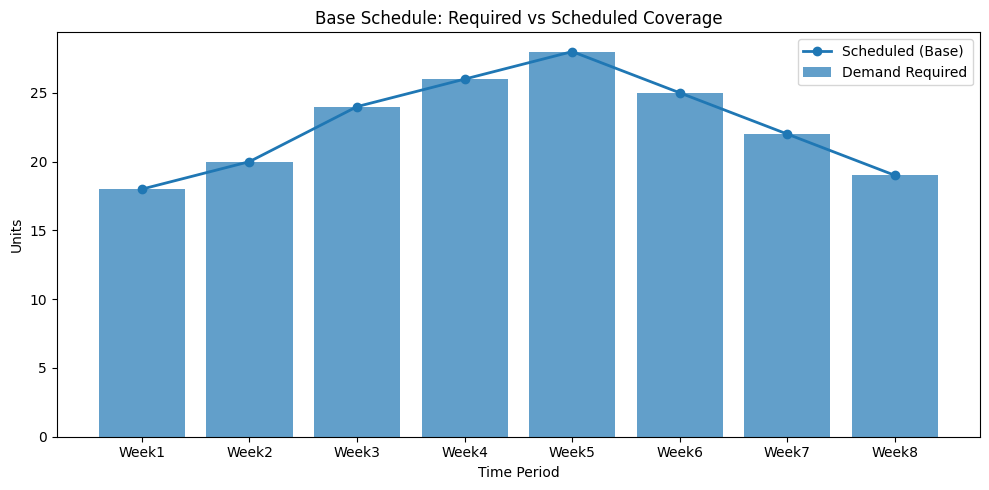

In [8]:
# Visualization: coverage chart (scheduled vs required)
plt.figure(figsize=(10, 5))
x = range(len(base_solution_df))
plt.bar(x, base_solution_df["demand_required"], alpha=0.7, label="Demand Required")
plt.plot(x, base_solution_df["scheduled_base"], marker="o", linewidth=2, label="Scheduled (Base)")
plt.xticks(x, base_solution_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Units")
plt.title("Base Schedule: Required vs Scheduled Coverage")
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 - Cost vs Service Tradeoff Analysis

In [9]:
# What-if scenario: higher service requirement (10% increase in required coverage)
service_multiplier = 1.10
demand_tradeoff = {p: demand[p] * service_multiplier for p in periods}

tradeoff_model = LpProblem("Scheduling_Tradeoff", LpMinimize)
scheduled_tradeoff = {p: LpVariable(f"scheduled_tradeoff_{p}", lowBound=0) for p in periods}

tradeoff_model += lpSum([scheduled_tradeoff[p] * cost[p] for p in periods]), "Total_Cost_Tradeoff"

for p in periods:
    tradeoff_model += scheduled_tradeoff[p] >= demand_tradeoff[p], f"Coverage_tradeoff_{p}"

# Capacity limit is kept the same
tradeoff_model += lpSum([scheduled_tradeoff[p] for p in periods]) <= total_capacity_limit, "Total_Capacity_Tradeoff"
tradeoff_model.solve()

tradeoff_solution_df = pd.DataFrame({
    "time_period": periods,
    "scheduled_tradeoff": [value(scheduled_tradeoff[p]) for p in periods]
})

comparison_df = base_solution_df[["time_period", "demand_required", "scheduled_base"]].merge(
    tradeoff_solution_df, on="time_period", how="left"
)

base_cost = value(base_model.objective)
tradeoff_cost = value(tradeoff_model.objective)

print(f"Base status: {LpStatus[base_model.status]} | Base total cost: {base_cost:.2f}")
print(f"Tradeoff status: {LpStatus[tradeoff_model.status]} | Tradeoff total cost: {tradeoff_cost:.2f}")
display(comparison_df)

Base status: Optimal | Base total cost: 3949.00
Tradeoff status: Optimal | Tradeoff total cost: 4343.90


,time_period,demand_required,scheduled_base,scheduled_tradeoff
0,Week1,18,18.0,19.8
1,Week2,20,20.0,22.0
2,Week3,24,24.0,26.4
3,Week4,26,26.0,28.6
4,Week5,28,28.0,30.8
5,Week6,25,25.0,27.5
6,Week7,22,22.0,24.2
7,Week8,19,19.0,20.9


The what-if scenario increases staffing requirements by 10%, which improves service quality by reducing wait times and improving customer support during busy weeks. However, this higher service level also increases total labor cost because more employees must be scheduled in each period. This demonstrates the tradeoff discussed in the chapter: better service levels require additional labor hours and therefore higher operating costs.

## Section 5 - Stakeholder Change and Reflection

In [10]:
# Stakeholder change example: service maximization
# Objective changed from cost minimization to service maximization

stakeholder_model = LpProblem("Scheduling_Stakeholder_Change", LpMaximize)

scheduled_stakeholder = {
    p: LpVariable(f"scheduled_stakeholder_{p}", lowBound=0)
    for p in periods
}

# Objective: maximize total staffing coverage / service level
stakeholder_model += lpSum(
    [scheduled_stakeholder[p] for p in periods]
), "Maximize_Total_Service"

# Minimum coverage constraints
for p in periods:
    stakeholder_model += (
        scheduled_stakeholder[p] >= demand[p],
        f"Coverage_stakeholder_{p}"
    )

# Total staffing capacity limit is kept the same
stakeholder_model += (
    lpSum([scheduled_stakeholder[p] for p in periods]) <= total_capacity_limit,
    "Total_Capacity_Stakeholder"
)

stakeholder_model.solve()

stakeholder_solution_df = pd.DataFrame({
    "time_period": periods,
    "scheduled_stakeholder": [
        value(scheduled_stakeholder[p]) for p in periods
    ]
})

final_compare_df = comparison_df.merge(
    stakeholder_solution_df,
    on="time_period",
    how="left"
)

print(f"Stakeholder status: {LpStatus[stakeholder_model.status]}")
if stakeholder_model.status == 1:
    print(f"Total service level: {value(stakeholder_model.objective):.2f}")

display(final_compare_df)

Stakeholder status: Optimal
Total service level: 209.00


,time_period,demand_required,scheduled_base,scheduled_tradeoff,scheduled_stakeholder
0,Week1,18,18.0,19.8,18.0
1,Week2,20,20.0,22.0,20.0
2,Week3,24,24.0,26.4,24.0
3,Week4,26,26.0,28.6,26.0
4,Week5,28,28.0,30.8,28.0
5,Week6,25,25.0,27.5,25.0
6,Week7,22,22.0,24.2,22.0
7,Week8,19,19.0,20.9,46.0


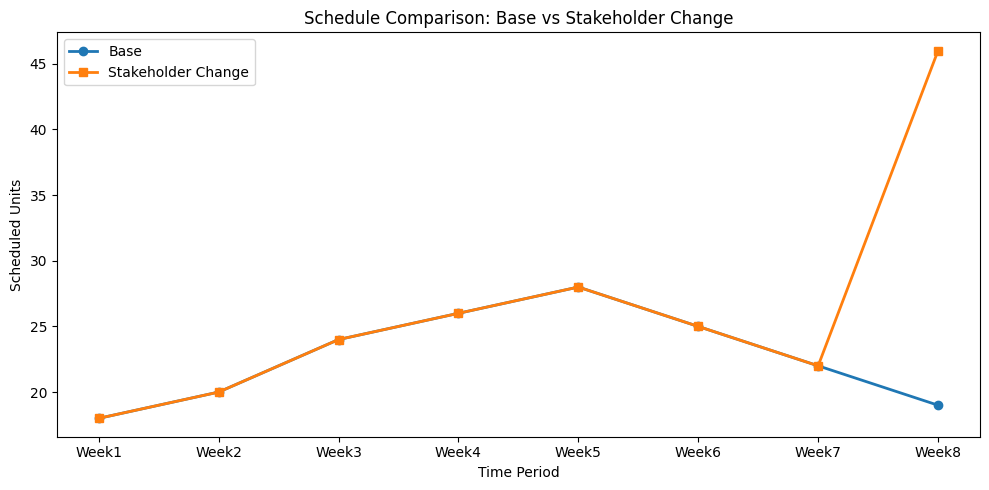

In [11]:
# Comparison visualization: base vs stakeholder-change schedule
plt.figure(figsize=(10, 5))
x = range(len(final_compare_df))
plt.plot(x, final_compare_df["scheduled_base"], marker="o", linewidth=2, label="Base")
plt.plot(x, final_compare_df["scheduled_stakeholder"], marker="s", linewidth=2, label="Stakeholder Change")
plt.xticks(x, final_compare_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Scheduled Units")
plt.title("Schedule Comparison: Base vs Stakeholder Change")
plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Stakeholder Change Interpretation

The stakeholder change modified the model objective from minimizing labor cost to maximizing service coverage across the eight-week period. In the base model, staffing levels were set to meet only the minimum required demand for each week, which kept costs as low as possible. After changing the objective, the model used all available staffing capacity to increase service levels, which resulted in additional employees being assigned beyond the minimum requirement.

This change matters for decision-making because mall management may prioritize customer experience during peak shopping periods, promotions, or holiday traffic. Higher staffing levels can improve customer assistance, reduce wait times, strengthen security presence, and improve overall shopper satisfaction. However, this also shows a tradeoff: maximizing service generally requires more labor hours and higher operational costs.

### 5.2 Professional Reflection

In this revised model, the objective changed from cost minimization (which can be seen visually in the chart in section 3.1 titled Base Schedule: Required vs Scheduled Coverage) to service maximization (this can be seen in the chart in section 5 titled Schedule Comparison: Base vs. Stakeholder Change), which significantly changed the staffing recommendations. Instead of scheduling only the minimum number of employees needed to satisfy weekly demand, the model allocated the full available staffing capacity to maximize service coverage across the eight-week period. As a result, week 8 received additional staff beyond the baseline requirement, demonstrating how objective functions directly influence scheduling outcomes.

This change is highly relevant in a mall setting because service quality directly affects customer satisfaction, sales opportunities, and security effectiveness. During busy shopping weeks, higher staffing levels can improve the shopping experience by reducing response times for customer inquiries, improving store support, and maintaining smoother operations. While this approach may increase labor usage, it may be justified when the goal is to improve customer experience and support business performance.

One important lesson I learned is that time-based scheduling problems are different from earlier allocation models because staffing decisions must be made for each individual time period rather than as one overall total. Chapter 9 goes over how coverage requirements must be met in every specific period, not on average, which makes scheduling more realistic and more complex for real-world business operations.